<a href="https://colab.research.google.com/github/Khalimovgeek/Kaggle_tesnorflow_trainings/blob/main/Question_Classifier_(Intent_Tagging).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
!pip install --upgrade --force-reinstall tensorflow-datasets

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.9/172.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.5/186.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 9.2 MB/s eta 0:00:00
  

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow.keras as keras
from tensorflow.keras import models, layers, utils, datasets
import numpy as np
from matplotlib import pyplot as plt

In [2]:
dataset_train, info = tfds.load('trec', split='train', with_info=True)
dataset_test = tfds.load('trec', split='test')

# # Look at the dataset structure / features
# print(info.features)

# # Take a look at a single training sample
# for sample in dataset_train.take(1):
#     text = sample['text'].numpy().decode('utf-8')
#     label_coarse = sample['label-coarse'].numpy()
#     print(f"Question: {text} | Class Label: {label_coarse}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/trec/incomplete.01LH4Q_1.0.0/trec-train.tfrecord-[0-9][0-9][0-9][0-9][0-9]…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/trec/incomplete.01LH4Q_1.0.0/trec-test.tfrecord-[0-9][0-9][0-9][0-9][0-9]-…

Dataset trec downloaded and prepared to /root/tensorflow_datasets/trec/1.0.0. Subsequent calls will reuse this data.


In [3]:
train_questions = []
train_labels = []

for sample in dataset_train:
    train_questions.append(sample["text"].numpy().decode("utf-8"))
    train_labels.append(sample["label-coarse"].numpy())

test_questions = []
test_labels = []

for sample in dataset_test:
    test_questions.append(sample["text"].numpy().decode("utf-8"))
    test_labels.append(sample["label-coarse"].numpy())

In [4]:
MAX_TOKENS = 10000
MAX_SEQUENCE_LENGTH = 50
EMBEDDING_DIM = 64
vectorize_layer = layers.TextVectorization(max_tokens=MAX_TOKENS,output_mode='int',output_sequence_length=MAX_SEQUENCE_LENGTH)
vectorize_layer.adapt(train_questions)


def model():
  model = models.Sequential(
      [
          vectorize_layer,
          layers.Embedding(MAX_TOKENS, EMBEDDING_DIM),
          layers.Conv1D(32,5,activation='relu', padding='same'),
          layers.BatchNormalization(),
          layers.Dropout(0.2),
          layers.MaxPooling1D(),

          layers.Conv1D(64,5,activation='relu', padding='same'),
          layers.BatchNormalization(),
          layers.Dropout(0.2),
          layers.GlobalMaxPooling1D(),

          layers.Dense(64,activation='relu'),
          layers.Dropout(0.5),
          layers.Dense(6, activation='softmax')
      ]
  )
  model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=keras.optimizers.Adam(
    learning_rate=0.001),
        metrics=['accuracy']
    )
  return model
my_model = model()
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
my_model(tf.constant(["Who invented Python?"]))

<tf.Tensor: shape=(1, 6), dtype=float32, numpy=
array([[0.16578953, 0.1656153 , 0.1681106 , 0.16627955, 0.16739881,
        0.16680624]], dtype=float32)>

In [6]:
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (1, 50)                │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (1, 50, 64)            │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (1, 50, 32)            │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 50, 32)            │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 50, 32)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (1, 25, 32)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (1, 25, 64)            │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 25, 64)            │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 25, 64)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (1, 64)                │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (1, 64)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 6)                 │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,510 (2.54 MB)

 Trainable params: 665,318 (2.54 MB)

 Non-trainable params: 192 (768.00 B)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',          # Watch validation loss
    patience=5,                  # Wait 2 epochs for improvement
    restore_best_weights=True,   # Restore the best model weights
    verbose=1
)

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",      # File to save
    monitor="val_loss",      # Metric to monitor
    save_best_only=True,     # Only save if validation loss improves
    mode="min",              # Lower val_loss is better
    verbose=1
)

In [9]:
import tensorflow as tf

train_questions = tf.constant(train_questions)
train_labels = tf.constant(train_labels)

test_questions = tf.constant(test_questions)
test_labels = tf.constant(test_labels)
history = my_model.fit(
    train_questions,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks = [checkpoint]

)

Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2177 - loss: 3.3154
Epoch 1: val_loss improved from None to 1.76873, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.2529 - loss: 2.3190 - val_accuracy: 0.2411 - val_loss: 1.7687
Epoch 2/10
135/137 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4029 - loss: 1.4431
Epoch 2: val_loss improved from 1.76873 to 1.66568, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4492 - loss: 1.3550 - val_accuracy: 0.3217 - val_loss: 1.6657
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5953 - loss: 1.0382
Epoch 3: val_loss improved from 1.66568 to 1.22099, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6177 - loss: 0.9851 - val_accuracy: 0.6489

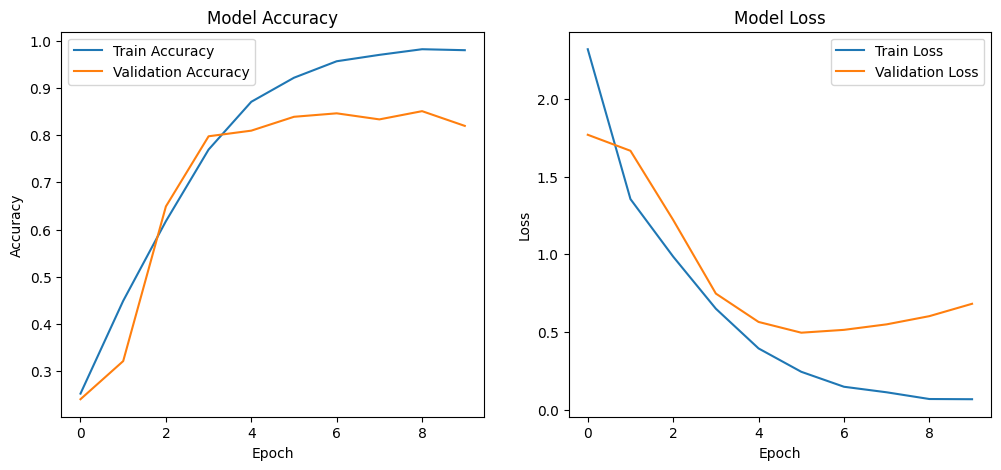

In [10]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [23]:
trained = models.load_model('/content/best_model.keras')


In [27]:
import tensorflow as tf

questions = tf.constant([
    "Who invented Python?",
    "Where is the Eiffel Tower?",
    "What does CPU stand for?"
], dtype=tf.string)

predictions = my_model(questions, training=False)

predicted = tf.argmax(predictions, axis=1).numpy()

label_map = {
    0: "DESC",
    1: "ENTY",
    2: "ABBR",
    3: "HUM",
    4: "NUM",
    5: "LOC"
}
for q, c in zip(questions.numpy(), predicted):
    print(q.decode() if isinstance(q, bytes) else q, "->", label_map[c])

Who invented Python? -> HUM
Where is the Eiffel Tower? -> LOC
What does CPU stand for? -> ABBR


In [17]:
print(my_model.input_shape)
print(my_model.inputs)

(1,)
[<KerasTensor shape=(1,), dtype=string, sparse=False, ragged=False, name=keras_tensor>]


In [18]:
print(type(questions))
print(questions.dtype)

<class 'numpy.ndarray'>
<U26


In [26]:
print(info.features["label-coarse"].names)

['DESC', 'ENTY', 'ABBR', 'HUM', 'NUM', 'LOC']


In [28]:
loss, accuracy = my_model.evaluate(test_questions, test_labels)

print(f"Test Accuracy: {accuracy:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8460 - loss: 0.7010
Test Accuracy: 0.8460


In [29]:
predictions = my_model(tf.constant(test_questions), training=False)
predicted = tf.argmax(predictions, axis=1).numpy()

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(test_labels, predicted)

print(cm)

[[135   2   0   0   1   0]
 [ 30  53   1   4   1   5]
 [  2   0   7   0   0   0]
 [  3   6   0  54   0   2]
 [  9   1   0   0 102   1]
 [  6   3   0   0   0  72]]


In [31]:
print(classification_report(
    test_labels,
    predicted,
    target_names=info.features["label-coarse"].names
))

              precision    recall  f1-score   support

        DESC       0.73      0.98      0.84       138
        ENTY       0.82      0.56      0.67        94
        ABBR       0.88      0.78      0.82         9
         HUM       0.93      0.83      0.88        65
         NUM       0.98      0.90      0.94       113
         LOC       0.90      0.89      0.89        81

    accuracy                           0.85       500
   macro avg       0.87      0.82      0.84       500
weighted avg       0.86      0.85      0.84       500

